[[1.         0.03823596 0.         0.03094922 0.05407381 0.05555556
  0.10540926 0.         0.         0.         0.03774257 0.
  0.         0.06876142 0.         0.        ]
 [0.03823596 1.         0.41561947 0.21300716 0.03721615 0.11470787
  0.14509525 0.14159847 0.29335941 0.18731716 0.28573838 0.20395079
  0.1467348  0.30761154 0.25235731 0.18074257]
 [0.         0.41561947 1.         0.18923271 0.         0.03774257
  0.         0.17471414 0.36854869 0.18490007 0.33333333 0.
  0.09656091 0.25692801 0.22645541 0.26761547]
 [0.03094922 0.21300716 0.18923271 1.         0.12049505 0.12379689
  0.         0.11461365 0.12951987 0.15161961 0.21025857 0.09433333
  0.11877114 0.09576506 0.1114172  0.19506394]
 [0.05407381 0.03721615 0.         0.12049505 1.         0.10814761
  0.10259784 0.         0.         0.         0.07347184 0.20602141
  0.13834289 0.06692745 0.06488857 0.08520286]
 [0.05555556 0.11470787 0.03774257 0.12379689 0.10814761 1.
  0.         0.         0.         0.0680

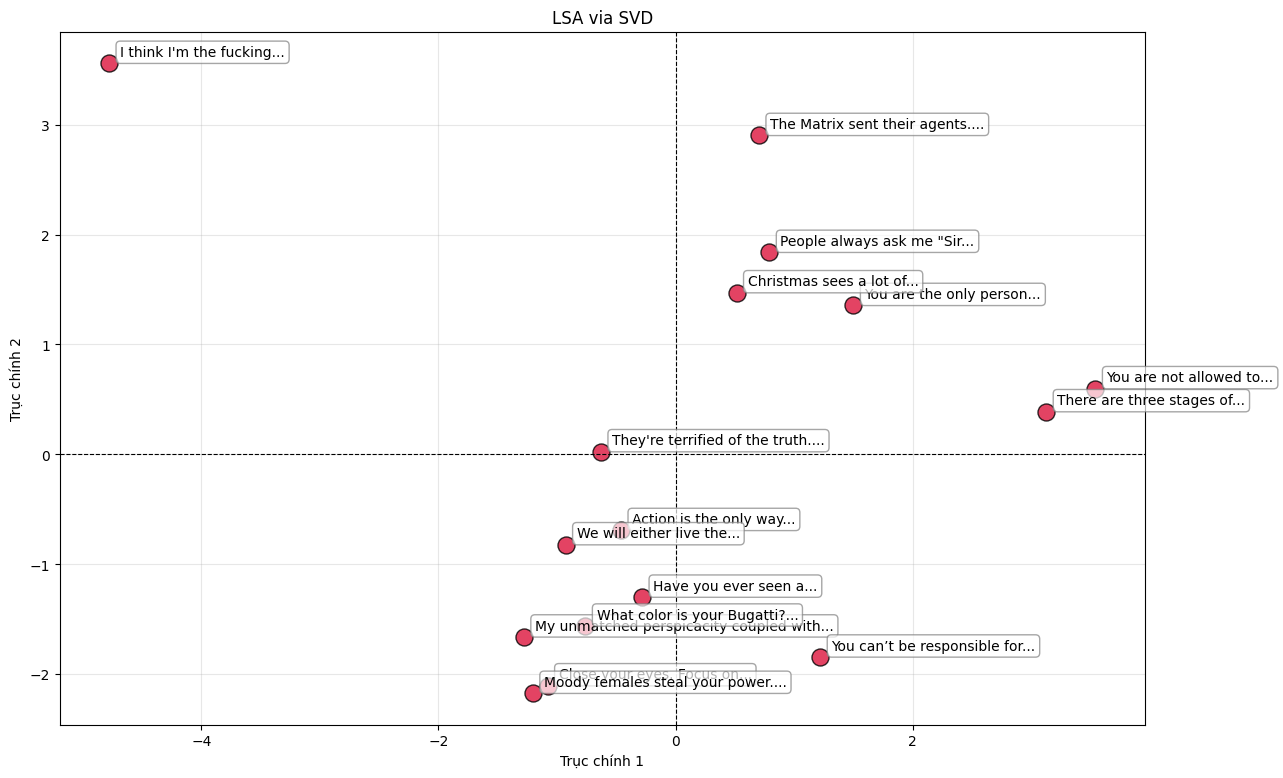

Test: 'Success is a journey, not a destination. Embrace the process, learn from your failures, and keep moving forward.'
Hàng xóm gần nhất: 'Action is the only way you’ll progress. Not talking. Not planning. And not reading books.'
Độ tương đồng Cosine lớn nhất: 0.4364
Nhãn dự đoán (Predicted Class): 【Motivation】

Test: 'They want everyone to be broke, weak, and depressed because a weak, broke, and depressed man is easy to control.'
Hàng xóm gần nhất: 'You are not allowed to be free. The Matrix does not want you to be free. The Matrix wants you to be a slave.'
Độ tương đồng Cosine lớn nhất: 0.4017
Nhãn dự đoán (Predicted Class): 【Conspiracy】



'Conspiracy'

In [1]:
import numpy as np
import matplotlib.pyplot as plt

cau = [
    "Close your eyes. Focus on making yourself feel excited, powerful. Imagine yourself destroying goals with ease.",
    "People always ask me \"Sir Andrew Tate is it true you and your friends are the Kings Of The Internet?\" I tell them of course it's true you big dummy.",
    "The Matrix sent their agents. They know Tristan and Andrew Tate are the kings of the internet and they are very afraid. Remember Top G predicted this.",
    "I think I'm the fucking man. I think I'm cool as fuck, and I'm happy with that. And I'm happy to live my life this way because I find it a source of motivation.",
    "Moody females steal your power. It’s dangerous for a man. A man must remain focused.",
    "My unmatched perspicacity coupled with shear indefaticability makes me a feared opponent in any realm of human endeavour.",
    "What color is your Bugatti?",
    "Action is the only way you’ll progress. Not talking. Not planning. And not reading books.",
    "You are the only person who can make this work, and you are the only person who can mess this up.",
    "We will either live the life of our dreams or die trying.",
    "Christmas sees a lot of erratic and irresponsible driving. Everybody please be extra careful on the roads. As you know lots of men drink too much alcohol and are forced to let their wives drive.",
    "You can’t be responsible for a dog if it doesn’t obey you, or a woman that doesn’t obey you.",
    "Have you ever seen a woman try and do anything competent?",
    "There are three stages of dealing with power. First, they cancel you. Second, they slander you, delete your access to social media, and arrest you. Third, they assassinate you.",
    "You are not allowed to be free. The Matrix does not want you to be free. The Matrix wants you to be a slave.",
    "They're terrified of the truth. Every lie they tell, every fake case they build, only proves that I am a massive threat to their system"



]

# thêm .strip()
vocab = sorted({w.strip('.,"?“”!') for s in cau for w in s.lower().split()})

def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        cleaned_w = w.strip('.,"?“”!')
        if cleaned_w in vocab:
            v[vocab.index(cleaned_w)] += 1
    return v

X = np.array([to_vector(s) for s in cau])

# Bài 1
mean_vector = X.mean(axis=0)
X_c = X - mean_vector

def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

def search(query, top_k=3):
    query_vec = to_vector(query).reshape(1, -1)
    scores = cosine_similarity(X, query_vec).flatten()

    top_indices = np.argsort(scores)[::-1][:top_k]

    print(f"Query: '{query}'\n")
    for rank, idx in enumerate(top_indices):
        print(f"Rank {rank+1}: Score {scores[idx]:.4f} | {cau[idx]}")

# test
print(cosine_similarity(X))
search("Andrew Tate internet matrix")
search("Focus and progress")

# Bài 2

# giảm chiều bằng SVD
U, S, Vt = np.linalg.svd(X_c, full_matrices=False)

# tọa độ 2D của mỗi câu
coords = U[:, :2] * S[:2]

plt.figure(figsize=(14, 9))
plt.scatter(coords[:, 0], coords[:, 1], color='crimson', edgecolors='black', s=150, alpha=0.8)

for i, sentence in enumerate(cau):
    short_label = " ".join(sentence.split()[:5]) + "..."
    plt.annotate(short_label, (coords[i, 0], coords[i, 1]),
                 xytext=(8, 5), textcoords='offset points',
                 fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))

# trang trí
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("LSA via SVD")
plt.xlabel("Trục chính 1")
plt.ylabel("Trục chính 2")
plt.grid(True, alpha=0.3)
plt.show()

# Bonus
# labels
labels = [
    "Motivation",
    "Bragging",
    "Conspiracy",
    "Bragging",
    "Gender Stereotype",
    "Bragging",
    "Bragging",
    "Motivation",
    "Motivation",
    "Motivation",
    "Gender Stereotype",
    "Gender Stereotype",
    "Gender Stereotype",
    "Conspiracy",
    "Conspiracy",
    "Conspiracy"

]

def predict_1nn(query_text, X_train, train_labels):
    query_vec = to_vector(query_text).reshape(1, -1)
    scores = cosine_similarity(X_train, query_vec).flatten()
    nearest_neighbor_idx = np.argmax(scores)

    predicted_label = train_labels[nearest_neighbor_idx]
    max_score = scores[nearest_neighbor_idx]

    print(f"Test: '{query_text}'")
    print(f"Hàng xóm gần nhất: '{cau[nearest_neighbor_idx]}'")
    print(f"Độ tương đồng Cosine lớn nhất: {max_score:.4f}")
    print(f"Nhãn dự đoán (Predicted Class): 【{predicted_label}】\n")

    return predicted_label

# test
test_cau_1 = "Success is a journey, not a destination. Embrace the process, learn from your failures, and keep moving forward."
predict_1nn(test_cau_1, X, labels)

test_cau_2 = "They want everyone to be broke, weak, and depressed because a weak, broke, and depressed man is easy to control."
predict_1nn(test_cau_2, X, labels)

### Nhận xét Bài 1 (Text)
### 1. Biểu diễn dữ liệu thành ma trận & Ý nghĩa các chiều
* **Kích thước (Shape) của ma trận X:** `(số_câu, số_từ_vựng)`.
* **Hàng:** Mỗi hàng là một câu trong tập dữ liệu
* **Cột:** Mỗi cột là cho một từ duy nhất (unique word). Giá trị mỗi ô chính là số lần từ đó xuất hiện.
### 2. Phép toán cơ bản
* **Shape trước khi trừ:** Ma trận `X` có kích thước 2D là `(số_câu, số_từ_vựng)`. Vector trung bình theo cột `mean_vector` có kích thước 1D là `(số_từ_vựng,)`.
* **Trừ trung bình:** Khi `X - mean_vector`, NumPy tự động áp dụng quy tắc broadcasting, copy ngầm vector 1D thành một ma trận 2D có cùng kích thước với `X`.
* **Shape sau khi trừ:** Ma trận `X_c` vẫn giữ nguyên dạng `(số_câu, số_từ_vựng)`.

### 3. Cosine Similarity
* `cosine_similarity` tính toán độ tương đồng bằng phép nhân ma trận. Nhưng phải normalize từng hàng trước (chia nó cho độ dài (L2 Norm) của chính nó).
### 4. Hàm Truy vấn (search)
* Hàm nhận vào một câu bất kỳ, đưa qua hàm `to_vector` để chuyển thành vector tần suất có cùng số chiều với không gian từ vựng gốc.
* Xong dùng `cosine_similarity` để quét vector này với toàn bộ ma trận dữ liệu `X`. Kết quả trả về một mảng điểm số cosine (dao động từ 0 đến 1 vì X chỉ chứa giá trị không âm).
* `np.argsort()` sắp xếp mảng điểm này theo thứ tự giảm dần, từ đó rút ra index của `top_k` câu có độ trùng lặp từ vựng cao nhất so với truy vấn gốc.
### 5. Nhận xét
Dựa trên điểm số Cosine giữa các cặp câu trong dữ liệu:
* **Cặp giống nhau nhất:** Là những câu có chứa sự lặp lại của các cụm từ khóa (keywords) cụ thể. Ví dụ, câu 2 ("Sir Andrew Tate... Kings Of The Internet") và câu 3 ("...Andrew Tate are the kings of the internet") có số cosine khá cao do chia sẻ rất nhiều từ vựng giống hệt nhau. Nó khớp với trực giác vì hai câu này đang nói về chủ đề gần giống nhau, đều có keyword như "Andrew Tate" và "kings of the internet".
* **Cặp khác biệt nhất:** Là các cặp câu có điểm cosine tiến về `0.0`. Ví dụ, câu hỏi "What color is your Bugatti?" và "Moody females...". Này cũng khớp với trực giác, thể hiện nội dung hai câu rẽ nhánh và không liên quan đến nhau. Tuy nhiên, vẫn có một số câu tương đồng về nghĩa nhưng lại không thể hiện cao trên cosine similarity.

### Nhận xét Bài 2 (Text)

* **Các chủ đề:**
* Các câu có chung từ khóa (ví dụ: các câu chứa "Andrew Tate", "Kings of the internet", "Matrix") nằm gần nhau.
* Các câu có từ khoá khác nhau bị đẩy ra xa.

**2. Liên hệ với Eigen/PCA và "trục chính" của dữ liệu:**
* SVD trừ trung bình về cơ bản là đang thực hiện PCA (Principal Component Analysis).
* Trục x và y là 2 thành phần chính ứng với 2 giá trị suy biến lớn nhất; tọa độ của mỗi câu trên các trục này được tính từ U·S, còn các eigenvector/loading thật sự (cho biết từ nào đóng góp vào mỗi trục) nằm trong Vt Cụ thể ở đây, trục chính đã tự động học cách phân tách cụm từ vựng "internet/matrix/Tate" ra khỏi cụm từ vựng "motivation/focus".

### Bonus
* Có thể ra các phân loại sai vì các từ thường dùng như "you", "and", "or",... làm tăng cosine similarity.

[[1.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         1.         0.23693955 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.05407381]
 [0.         0.23693955 1.         0.         0.         0.
  0.         0.         0.         0.         0.05270463 0.
  0.         0.         0.10127394 0.        ]
 [0.         0.         0.         1.         0.09245003 0.
  0.         0.03928371 0.         0.10540926 0.03402069 0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.09245003 1.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.06933752 0.         0.        ]
 [0.         0.         0.         0.         0.         1.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        

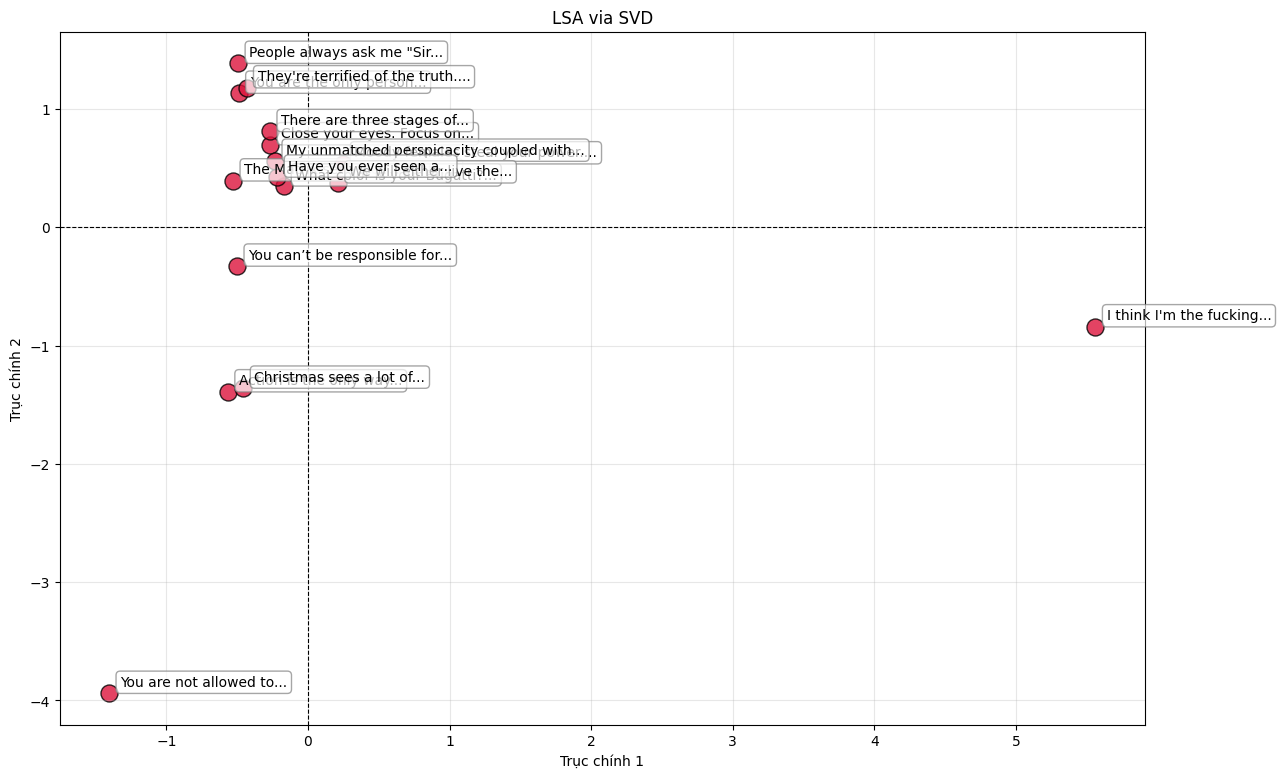

Test: 'Success is a journey, not a destination. Embrace the process, learn from your failures, and keep moving forward.'
Hàng xóm gần nhất: 'Action is the only way you’ll progress. Not talking. Not planning. And not reading books.'
Độ tương đồng Cosine lớn nhất: 0.7071
Nhãn dự đoán (Predicted Class): 【Motivation】

Test: 'They want everyone to be broke, weak, and depressed because a weak, broke, and depressed man is easy to control.'
Hàng xóm gần nhất: 'You are not allowed to be free. The Matrix does not want you to be free. The Matrix wants you to be a slave.'
Độ tương đồng Cosine lớn nhất: 0.3922
Nhãn dự đoán (Predicted Class): 【Conspiracy】



'Conspiracy'

In [2]:
#loại bỏ các từ thường dùng nhưng không nhiều nghĩa
import numpy as np
import matplotlib.pyplot as plt

cau = [
    "Close your eyes. Focus on making yourself feel excited, powerful. Imagine yourself destroying goals with ease.",
    "People always ask me \"Sir Andrew Tate is it true you and your friends are the Kings Of The Internet?\" I tell them of course it's true you big dummy.",
    "The Matrix sent their agents. They know Tristan and Andrew Tate are the kings of the internet and they are very afraid. Remember Top G predicted this.",
    "I think I'm the fucking man. I think I'm cool as fuck, and I'm happy with that. And I'm happy to live my life this way because I find it a source of motivation.",
    "Moody females steal your power. It’s dangerous for a man. A man must remain focused.",
    "My unmatched perspicacity coupled with shear indefaticability makes me a feared opponent in any realm of human endeavour.",
    "What color is your Bugatti?",
    "Action is the only way you’ll progress. Not talking. Not planning. And not reading books.",
    "You are the only person who can make this work, and you are the only person who can mess this up.",
    "We will either live the life of our dreams or die trying.",
    "Christmas sees a lot of erratic and irresponsible driving. Everybody please be extra careful on the roads. As you know lots of men drink too much alcohol and are forced to let their wives drive.",
    "You can’t be responsible for a dog if it doesn’t obey you, or a woman that doesn’t obey you.",
    "Have you ever seen a woman try and do anything competent?",
    "There are three stages of dealing with power. First, they cancel you. Second, they slander you, delete your access to social media, and arrest you. Third, they assassinate you.",
    "You are not allowed to be free. The Matrix does not want you to be free. The Matrix wants you to be a slave.",
    "They're terrified of the truth. Every lie they tell, every fake case they build, only proves that I am a massive threat to their system"



]

filler_words = {'the', 'and', 'is', 'a', 'of', 'to', 'in', 'it', 'for', 'on', 'with',
              'me', 'you', 'your', 'are', 'i', 'my', 'this', 'that', 'they', 'their'}

vocab = sorted({w.strip('.,"?“”!') for s in cau for w in s.lower().split()
                if w.strip('.,"?“”!') not in filler_words})

def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        cleaned_w = w.strip('.,"?“”!')
        if cleaned_w in vocab:
            v[vocab.index(cleaned_w)] += 1
    return v

X = np.array([to_vector(s) for s in cau])

# Bài 1
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True) #để độ dài câu không ảnh hưởng

mean_vector = X.mean(axis=0)
X_c = X - mean_vector

def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

def search(query, top_k=3):
    query_vec = to_vector(query).reshape(1, -1)
    scores = cosine_similarity(X, query_vec).flatten()

    top_indices = np.argsort(scores)[::-1][:top_k]

    print(f"Query: '{query}'\n")
    for rank, idx in enumerate(top_indices):
        print(f"Rank {rank+1}: Score {scores[idx]:.4f} | {cau[idx]}")

# test
print(cosine_similarity(X))
search("Andrew Tate internet matrix")
search("Focus and progress")

# Bài 2

# giảm chiều bằng SVD
U, S, Vt = np.linalg.svd(X_c, full_matrices=False)

# tọa độ 2D của mỗi câu
coords = U[:, :2] * S[:2]

plt.figure(figsize=(14, 9))
plt.scatter(coords[:, 0], coords[:, 1], color='crimson', edgecolors='black', s=150, alpha=0.8)

for i, sentence in enumerate(cau):
    short_label = " ".join(sentence.split()[:5]) + "..."
    plt.annotate(short_label, (coords[i, 0], coords[i, 1]),
                 xytext=(8, 5), textcoords='offset points',
                 fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))

# trang trí
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("LSA via SVD")
plt.xlabel("Trục chính 1")
plt.ylabel("Trục chính 2")
plt.grid(True, alpha=0.3)
plt.show()

# Bonus
# labels
labels = [
    "Motivation",
    "Bragging",
    "Conspiracy",
    "Bragging",
    "Gender Stereotype",
    "Bragging",
    "Bragging",
    "Motivation",
    "Motivation",
    "Motivation",
    "Gender Stereotype",
    "Gender Stereotype",
    "Gender Stereotype",
    "Conspiracy",
    "Conspiracy",
    "Conspiracy"

]

def predict_1nn(query_text, X_train, train_labels):
    query_vec = to_vector(query_text).reshape(1, -1)
    scores = cosine_similarity(X_train, query_vec).flatten()
    nearest_neighbor_idx = np.argmax(scores)

    predicted_label = train_labels[nearest_neighbor_idx]
    max_score = scores[nearest_neighbor_idx]

    print(f"Test: '{query_text}'")
    print(f"Hàng xóm gần nhất: '{cau[nearest_neighbor_idx]}'")
    print(f"Độ tương đồng Cosine lớn nhất: {max_score:.4f}")
    print(f"Nhãn dự đoán (Predicted Class): 【{predicted_label}】\n")

    return predicted_label

# test
test_cau_1 = "Success is a journey, not a destination. Embrace the process, learn from your failures, and keep moving forward."
predict_1nn(test_cau_1, X, labels)

test_cau_2 = "They want everyone to be broke, weak, and depressed because a weak, broke, and depressed man is easy to control."
predict_1nn(test_cau_2, X, labels)


Một số câu kiểm thử bị phân loại sai vào nhóm do số lần chữ "you" xuất hiện nhiều.

Do đó đã thử lọc bớt một số từ filler. Tuy nhiên cho dù sử dụng bộ lọc, kết quả label vẫn **tương tự** không sử dụng bộ lọc.

Nhưng có sự thay đổi về cosine similarity.